<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
sent_tokenize(dataset['train'][1]['text'])#['features']

['"I Am Curious: Yellow" is a risible and pretentious steaming pile.',
 "It doesn't matter what one's political views are because this film can hardly be taken seriously on any level.",
 "As for the claim that frontal male nudity is an automatic NC-17, that isn't true.",
 "I've seen R-rated films with male nudity.",
 'Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia?',
 "Nowhere, because they don't exist.",
 'The same goes for those crappy cable shows: schlongs swinging in the breeze but not a clitoris in sight.',
 "And those pretentious indie movies like The Brown Bunny, in which we're treated to the site of Vincent Gallo's throbbing johnson, but not a trace of pink visible on Chloe Sevigny.",
 'Before crying (or implying) "double-standard" in matters of nudity, the mentally obtuse should take into account one unavoidably obvious anatomical difference between men and women: there are no genitals on display when actress

In [8]:
sentences = []
word_threshold = 32
# word_threshold = 1e10

# Получить отдельные предложения и поместить их в sentences
for doc in dataset['train']:
  doc_sents = sent_tokenize(doc['text'])
  for doc_sent in doc_sents:
    doc_sent_words = word_tokenize(doc_sent)
    if len(doc_sent_words) < word_threshold:
      sentences.append(doc_sent.lower())
  # break
print(len(sentences))

198801


In [9]:
sentences[:3]

['i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967.',
 "really, the sex and nudity scenes are few and far between, even then it's not shot like some cheaply made porno.",
 'while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema.']

In [10]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [11]:
words = Counter()

# Расчет встречаемости слов
for sentence in sentences:
    words.update(word_tokenize(sentence))

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [12]:
vocab = set()
vocab_size = 40000

# Наполнение словаря
vocab.add('<unk>')
vocab.add('<bos>')
vocab.add('<eos>')
vocab.add('<pad>')

for word, freq in words.most_common(vocab_size):
    vocab.add(word)

In [13]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [14]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [15]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [16]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        # Допишите код здесь
        tokenized_sentence.append(self.bos_id)
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx].lower())]
        tokenized_sentence.append(self.eos_id)

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [17]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [18]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [19]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [20]:
def train_model(model, num_epoch, criterion, optimizer, dataloader):
    # Напишите код здесь

    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, dataloader))

    return losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [21]:
class LanguageModel(nn.Module):
    def __init__(self,
                 vocab_size, emb_size,
                 rnn, rnn_hiddensize, rnn_num_layers, rnn_dropout, bidirectional,
                 dropout, non_lin, linear_out_dims: List[int]):
        super().__init__()

        # Опишите свою нейронную сеть здесь
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.rnn = rnn(emb_size, rnn_hiddensize, rnn_num_layers, dropout=rnn_dropout, bidirectional=bidirectional, batch_first=True, )
        self.non_lin = non_lin()
        self.dropout = nn.Dropout(dropout)
        self.linears = nn.ModuleList()
        inp_dim = rnn_hiddensize
        for out_dim in linear_out_dims:
            self.linears.append(nn.Linear(inp_dim, out_dim))
            inp_dim=out_dim
        self.projection = nn.Linear(linear_out_dims[-1], vocab_size)


    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embddings = self.embedding(input_batch)
        output, _ = self.rnn(embddings)
        for linear in self.linears:
            output = self.non_lin(output)
            output = linear(output)
            output = self.dropout(output)
        output = self.non_lin(output)
        output = self.projection(output)

        return output

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.203870967809749, 5.393438937677459, 5.204198937404568, 5.096409771198816, 5.031375677856053]
Train perplexities: [252.84105131804512, 186.80153175409245, 162.7181634818558, 148.89600539265, 139.52329480024662]
Eval perp: 143.59


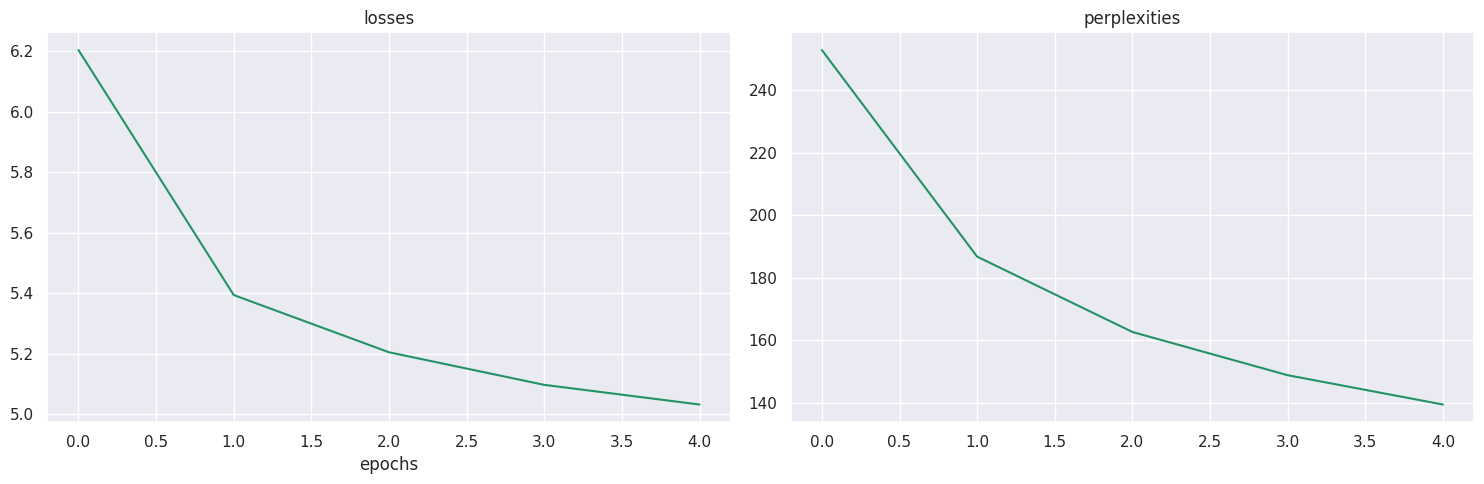

In [ ]:
model = LanguageModel(
    len(vocab), emb_size=32,
    rnn=nn.RNN, rnn_hiddensize=64, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 142.95


### Второй эксперимент (2 балла) - GRU и LSTM

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.165901668975168, 5.372052486922985, 5.169732019005528, 5.055112410627443, 4.9775557310851655]
Train perplexities: [249.99422193973754, 182.62750797778105, 156.91199924287926, 142.01746272657152, 132.37865141717447]
Eval perp: 135.86


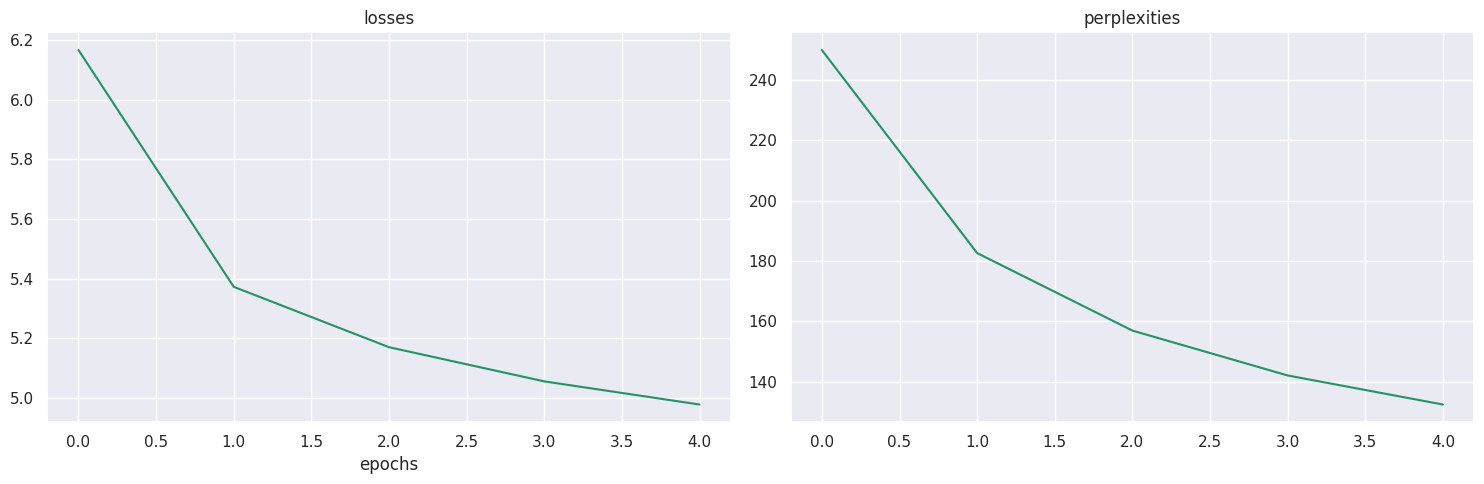

In [ ]:
# GRU
model = LanguageModel(
    len(vocab), emb_size=32,
    rnn=nn.GRU, rnn_hiddensize=64, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 135.57


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.282801872477451, 5.451364948014914, 5.215417539699367, 5.0855858753692305, 4.993646320563982]
Train perplexities: [278.46917846139553, 193.13567619293042, 163.24321577420469, 145.62598351672688, 133.55094945881507]
Eval perp: 136.76


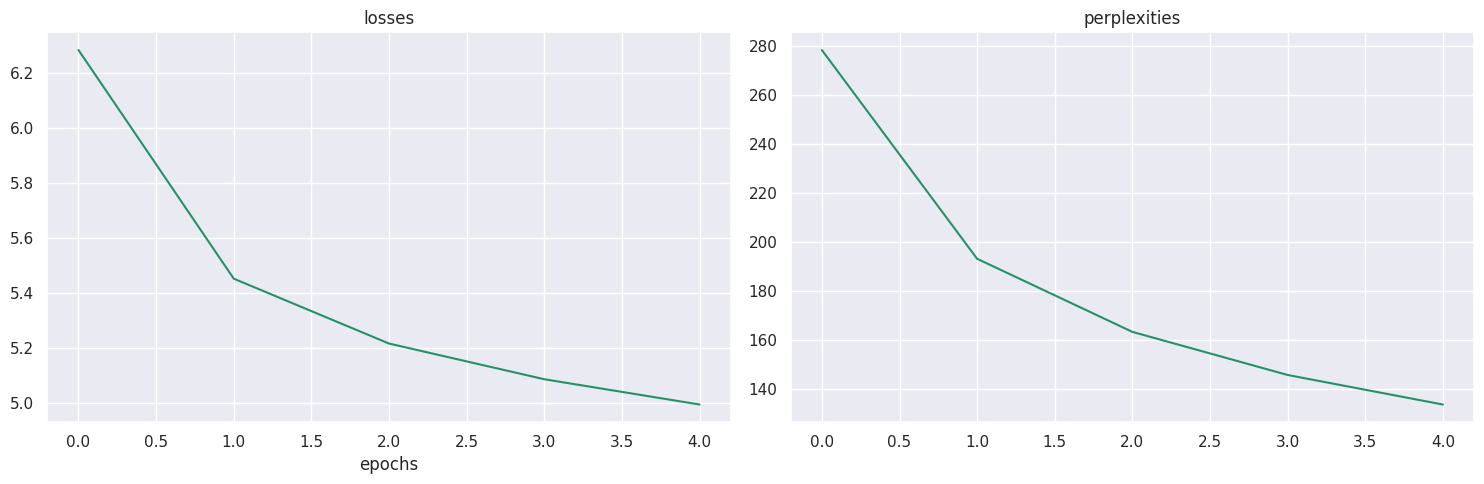

In [ ]:
# LSTM
model = LanguageModel(
    len(vocab), emb_size=32,
    rnn=nn.LSTM, rnn_hiddensize=64, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 136.33


### Третий эксперимент - LSTM и большие эмбеддинги

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.138318566669884, 5.331314855684509, 5.115249428937057, 4.990921116412309, 4.904323500390026]
Train perplexities: [241.7490261013433, 172.91870500805487, 147.32157299505158, 131.91702953040937, 121.59492652260865]
Eval perp: 124.96


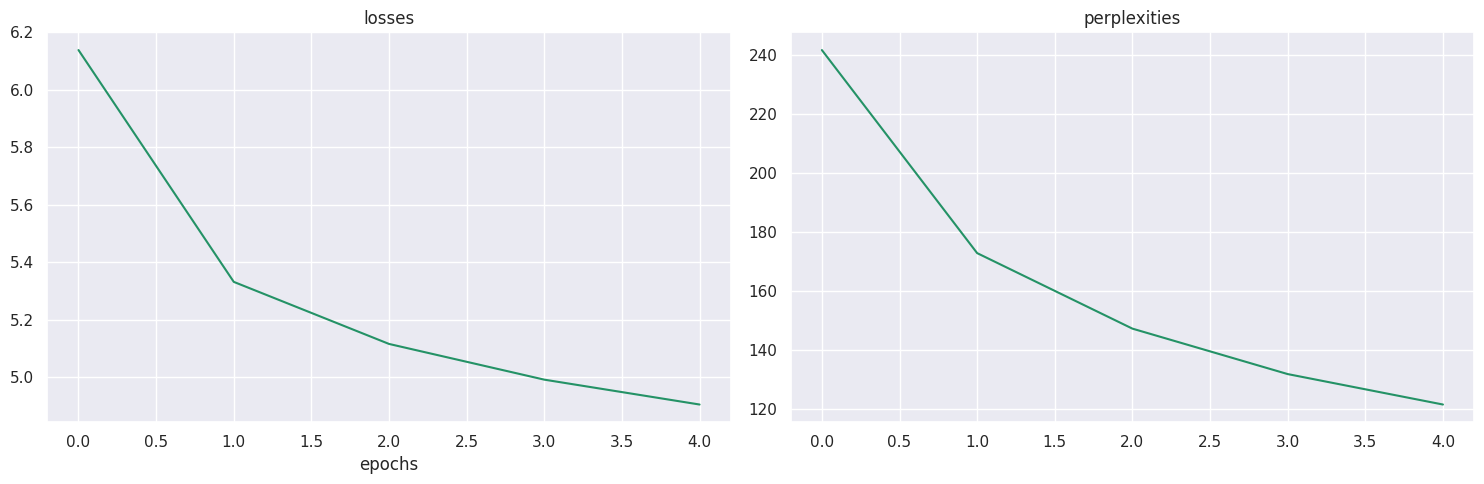

In [ ]:
# LSTM и большая ширина эмбеддингов
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=64, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 124.64


### Четвертый эксперимент - LSTM, большие эмбеддинги и большая ширина слоев

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.2370697617626725, 5.329745389335307, 5.080575906549456, 4.946269607313774, 4.8515247738562755]
Train perplexities: [251.48582140553506, 166.97289859836175, 140.16189199556578, 124.8030319827656, 114.15265193334628]
Eval perp: 117.54


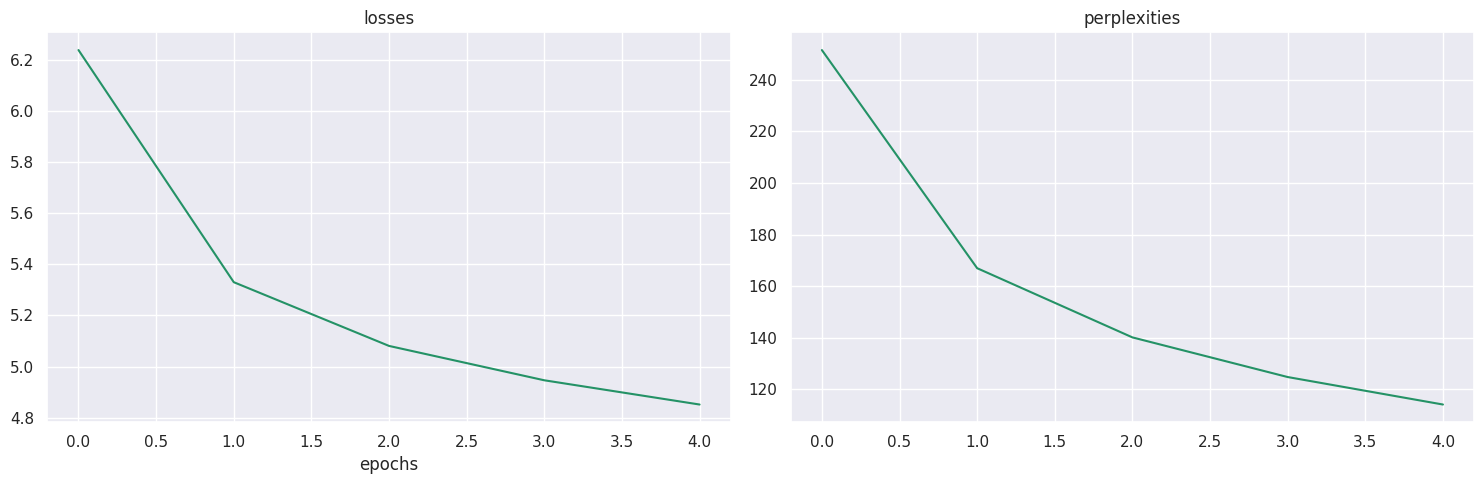

In [ ]:
# LSTM, большие эмбеддинги, большая ширина слоев рек слоя
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=128, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 117.12


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [5.832243287937351, 5.12273047877624, 4.919682774348117, 4.789488376577536, 4.6937223946194635]
Train perplexities: [186.77185290605908, 140.05389131774658, 119.05642528948243, 106.04700473653436, 97.02872063781787]
Eval perp: 101.38


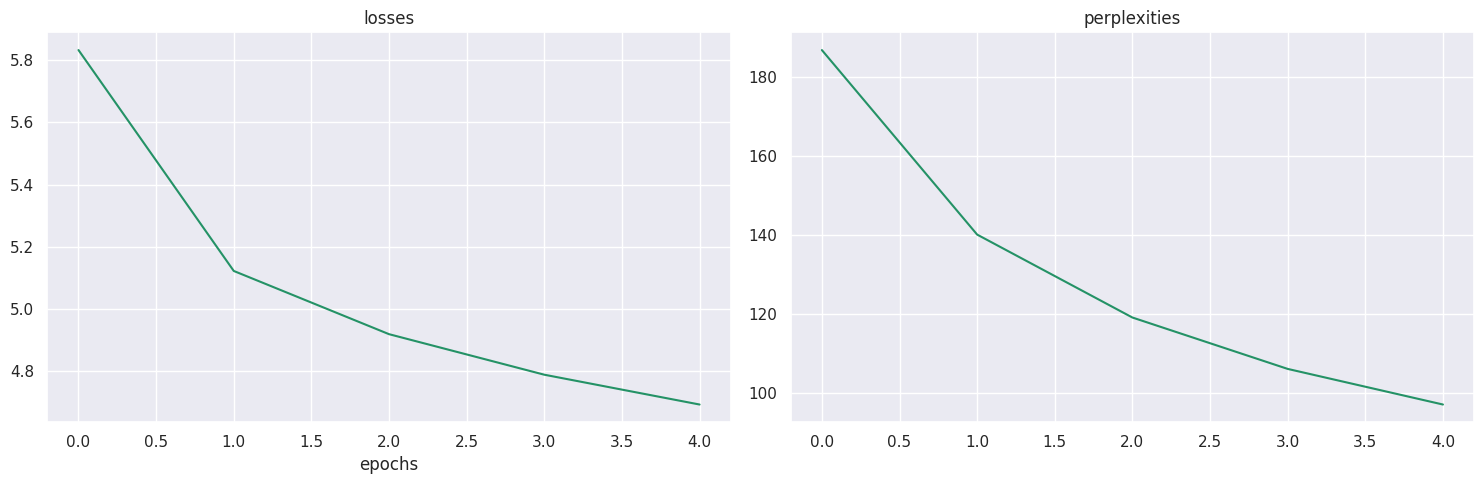

In [ ]:
# LSTM, большие эмбеддинги, большая ширина слоев рек слоя и большая ширина слоев лин слоя
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=128, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[128],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 101.14


### Пятый эксперимент - LSTM, большие эмбеддинги, большая ширина слоев, больше слоев

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.109477342373886, 5.308502384471203, 5.067619922174529, 4.919257485856956, 4.810755768804328]
Train perplexities: [243.69215011289785, 167.34006945854796, 138.41541273710905, 121.52729704067387, 110.30650184121903]
Eval perp: 114.20


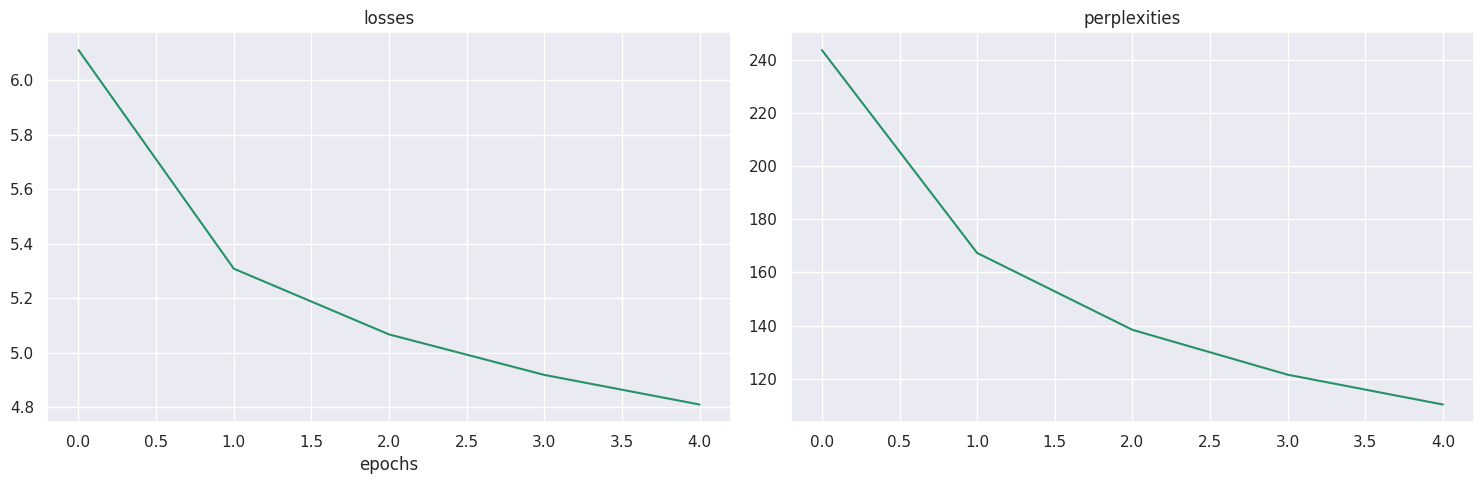

In [ ]:
# LSTM, большие эмбеддинги, большая ширина слоев рек слоя, большая ширина слоев лин слоя, больше рек слоев
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=128, rnn_num_layers=2, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[128],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 113.87


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [6.194192513475856, 5.363358285095264, 5.129502361662812, 4.998969617430855, 4.908125958323766]
Train perplexities: [253.11177005292137, 177.36414216855601, 147.32339531552475, 131.35641039405633, 121.00112521600455]
Eval perp: 124.48


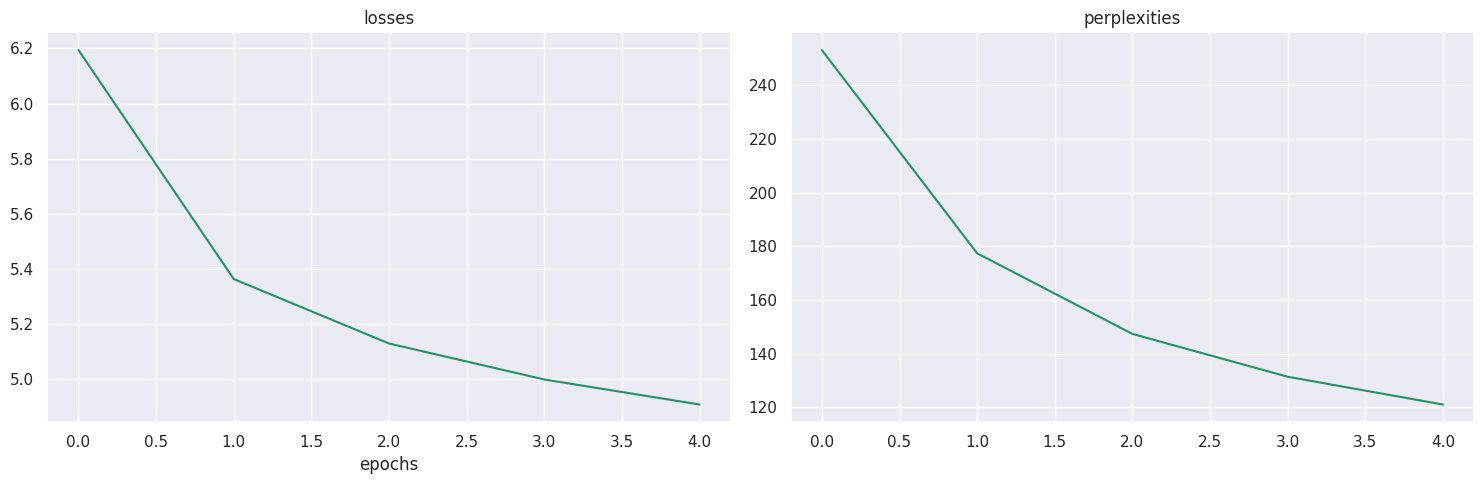

In [ ]:
# LSTM, большие эмбеддинги, большая ширина слоев рек слоя, большая ширина слоев лин слоя, больше лин слоев
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=128, rnn_num_layers=1, rnn_dropout=0, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[128, 64],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 124.11


### Шестой эксперимент - LSTM, большие эмбеддинги, большая ширина слоев, больше рек дропаут

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Train losses: [5.8307504416087514, 5.131604886304344, 4.928915865845193, 4.797337468362871, 4.699491680771328]
Train perplexities: [188.36060901006573, 141.88025522884206, 120.34490821328934, 107.06349931565006, 97.641098949282]
Eval perp: 101.96


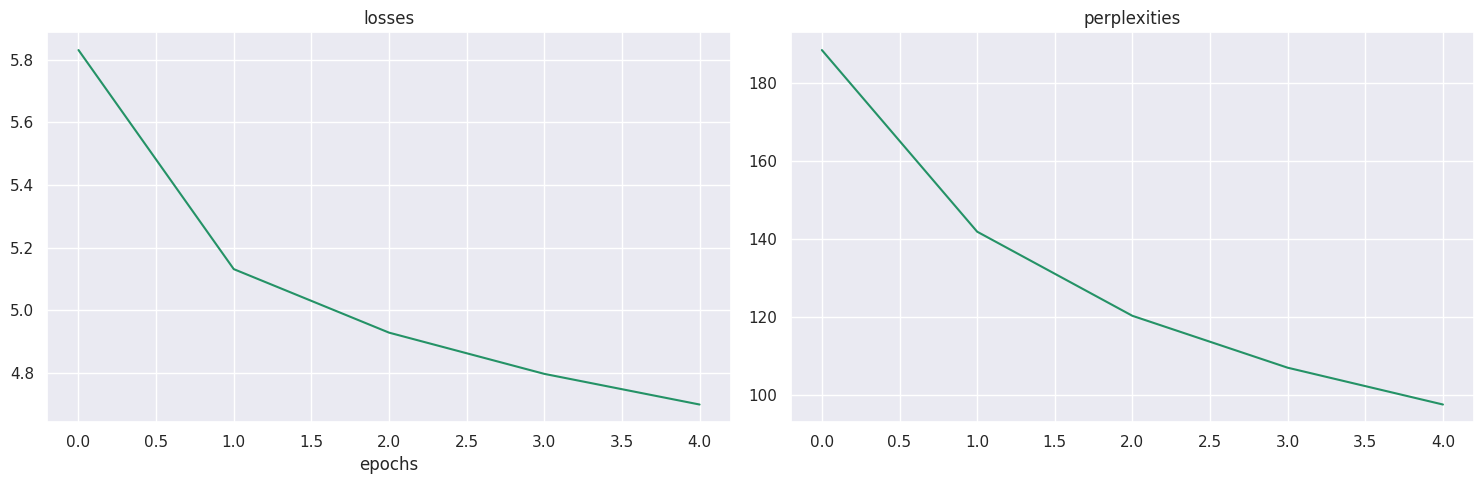

In [ ]:
# LSTM, большие эмбеддинги, большая ширина слоев рек слоя, большая ширина слоев лин слоя, больше рек дропаут
model = LanguageModel(
    len(vocab), emb_size=64,
    rnn=nn.LSTM, rnn_hiddensize=128, rnn_num_layers=1, rnn_dropout=0.1, bidirectional=False,
    dropout=0.1, non_lin=nn.Tanh, linear_out_dims=[128],
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epoch = 5

losses, perplexities = train_model(model, num_epoch, criterion, optimizer, train_dataloader)

print(f'Train losses: {losses}')
print(f'Train perplexities: {perplexities}')
print(f'Eval perp: {evaluate(model, criterion, eval_dataloader):.2f}')

fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(losses)
axs[0].set_title('losses')
axs[0].set_xlabel("epochs")
axs[1].plot(perplexities)
axs[1].set_title('perplexities')
axs[0].set_xlabel("epochs")
plt.tight_layout()
plt.show()

In [ ]:
print(f'Test perp: {evaluate(model, criterion, test_dataloader):.2f}')

Test perp: 101.70


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

## Отчет по экспериментам

Проведены 6 экспериментов с различными конфигурациями модели `LanguageModel`, основанной на рекуррентных сетях (RNN, GRU, LSTM) для задачи языкового моделирования на датасете IMDB. В качестве метрики качества использовалась перплексия на тестовой выборке.

| Эксперимент | RNN тип | Размер эмбеддингов | Размер скрытого состояния RNN | Количество слоев RNN | RNN Dropout | Dropout (линейные слои) | Размеры линейных слоев | Perplexity (Test) |
|---|---|---|---|---|---|---|---|---|
| 1 | RNN | 32 | 64 | 1 | 0 | 0.1 | [64] | 142.95 |
| 2 | GRU | 32 | 64 | 1 | 0 | 0.1 | [64] | 135.57 |
| 3 | LSTM | 32 | 64 | 1 | 0 | 0.1 | [64] | 136.33 |
| 4 | LSTM | 64 | 64 | 1 | 0 | 0.1 | [64] | 124.64 |
| 5 | LSTM | 64 | 128 | 1 | 0 | 0.1 | [64] | 117.12 |
| 6 | LSTM | 64 | 128 | 1 | 0 | 0.1 | [128] | 101.14 |
| 7 | LSTM | 64 | 128 | 2 | 0 | 0.1 | [128] | 113.87 |
| 8 | LSTM | 64 | 128 | 1 | 0.1 | 0.1 | [128] | 101.70 |


**Выводы:**

* Использование GRU и LSTM показало лучшие результаты по сравнению с простой RNN.
* Увеличение размера эмбеддингов (с 32 до 64) привело к улучшению качества.
* Увеличение размера скрытого состояния RNN (с 64 до 128) также снизило перплексию.
* Увеличение размера линейных слоев после RNN положительно сказалось на результате.
* Увеличение количества слоев RNN (с 1 до 2) не привело к значительному улучшению в данном случае.
* Добавление Dropout в RNN слой с `num_layers=1` вызвало предупреждение, но тем не менее показало близкий результат к модели без RNN Dropout, но с более широким линейным слоем.

**Идеи по улучшению качества моделей:**

* **Увеличение количества эпох обучения:** Возможно, модели еще не достигли полной сходимости за 5 эпох.
* **Подбор learning rate:** Использование различных стратегий изменения learning rate в процессе обучения может улучшить результат.
* **Добавление других техник регуляризации:** Использование BatchNorm или LayerNorm может помочь в стабилизации обучения и улучшении качества.
* **Эксперименты с двунаправленными RNN:** Использование `bidirectional=True` в RNN слоях может позволить модели учитывать как прошлое, так и будущее контекстное окружение слова.
* **Увеличение размера словаря:** Включение большего количества менее часто встречающихся слов в словарь может улучшить способность модели генерировать более разнообразный текст, но также может увеличить разреженность данных и потребовать большего объема данных для обучения.
* **Использование предобученных эмбеддингов:** Использование предобученных эмбеддингов (например, Word2Vec, GloVe) может помочь модели лучше понять семантические отношения между словами.
* **Трансформерные модели:** Для более сложных задач языкового моделирования можно рассмотреть использование трансформерных архитектур, которые показывают state-of-the-art результаты.